In [1]:
!pip install transformers torch nltk evaluate datasets sentence-transformers matplotlib numpy pandas seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 KB 3.1 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer, util
import nltk
from nltk.tokenize import sent_tokenize

In [15]:
nltk.download('punkt')

sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

import requests
import json

OLLAMA_API = "http://localhost:11434/api"

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [16]:
def generate_samples(prompt, n_samples=5, temperature=0.7):
    samples = []
    
    for _ in range(n_samples):
        response = requests.post(
            f"{OLLAMA_API}/generate",
            json={
                "model": "mistral:7b",
                "prompt": prompt,
                "temperature": temperature,
                "stream": False
            }
        )
        
        if response.status_code == 200:
            result = response.json()
            samples.append(result['response'])
        else:
            print(f"Error: {response.status_code}")
            print(response.text)
    
    return samples

def extract_sentences(text):
    return sent_tokenize(text)

def compute_sentence_embeddings(sentences):
    return sentence_model.encode(sentences)

def compute_pairwise_similarities(embeddings):
    return util.cos_sim(embeddings, embeddings).numpy()

def compute_selfcheck_score(samples):
    all_sentences = [extract_sentences(sample) for sample in samples]
    
    flat_sentences = [sent for sample_sents in all_sentences for sent in sample_sents]
    
    embeddings = compute_sentence_embeddings(flat_sentences)
    
    similarities = compute_pairwise_similarities(embeddings)
    
    sentence_to_sample = []
    for i, sample_sents in enumerate(all_sentences):
        sentence_to_sample.extend([i] * len(sample_sents))
    
    n_sentences = len(flat_sentences)
    sentence_scores = []
    
    for i in range(n_sentences):
        sample_i = sentence_to_sample[i]
        
        other_samples_sims = []
        
        for j in range(n_sentences):
            sample_j = sentence_to_sample[j]
            if sample_i != sample_j:
                other_samples_sims.append(similarities[i, j])
        
        if other_samples_sims:
            sentence_scores.append(np.mean(other_samples_sims))
    
    return np.mean(sentence_scores) if sentence_scores else 0.0

In [17]:
def test_hallucination(prompt, n_samples=5, temperature=0.7):
    print(f"Testing prompt: {prompt}")
    print("Generating samples...")
    
    samples = generate_samples(prompt, n_samples, temperature)
    
    print("\nSample outputs:")
    for i, sample in enumerate(samples):
        print(f"\nSample {i+1}:")
        print(sample[:300] + "..." if len(sample) > 300 else sample)
    
    score = compute_selfcheck_score(samples)
    print(f"\nSelfCheckGPT consistency score: {score:.4f}")
    print(f"Interpretation: {'Low risk of hallucination' if score > 0.7 else 'Medium risk of hallucination' if score > 0.5 else 'High risk of hallucination'}")
    
    return samples, score

In [18]:
test_prompts = [
    "Explain the process of photosynthesis.",
    "What are the main achievements of the scientist Albert Einstein?",
    "Describe the cultural impact of the fictional movie 'The Rise of Atlantis' released in 2018.",
    "What happened during the Martian War of 2050?",
    "Explain the health benefits of drinking water."
]

results = {}

for prompt in test_prompts:
    samples, score = test_hallucination(prompt)
    results[prompt] = {
        "score": score,
        "samples": samples
    }

Testing prompt: Explain the process of photosynthesis.
Generating samples...

Sample outputs:

Sample 1:
1. Light Reaction (Photophosphorylation): This is the initial step of photosynthesis where light energy is absorbed by chlorophyll pigments in the thylakoid membrane of the chloroplasts within plant cells. The absorbed light energy splits water molecules into oxygen, protons, and electrons.

   - Th...

Sample 2:
 Photosynthesis is a fundamental biological process that plants, algae, and certain bacteria carry out to convert light energy into chemical energy, which they later use to fuel their growth and reproduction. The overall equation for photosynthesis can be written as:

6 CO2 + 6 H2O + light energy → ...

Sample 3:
 Photosynthesis is a fundamental biological process that converts carbon dioxide, water, and light energy into glucose (a type of sugar) and oxygen in green plants, algae, and some bacteria. Here's an overview of the steps involved:

1. **Light-dependent reactions*

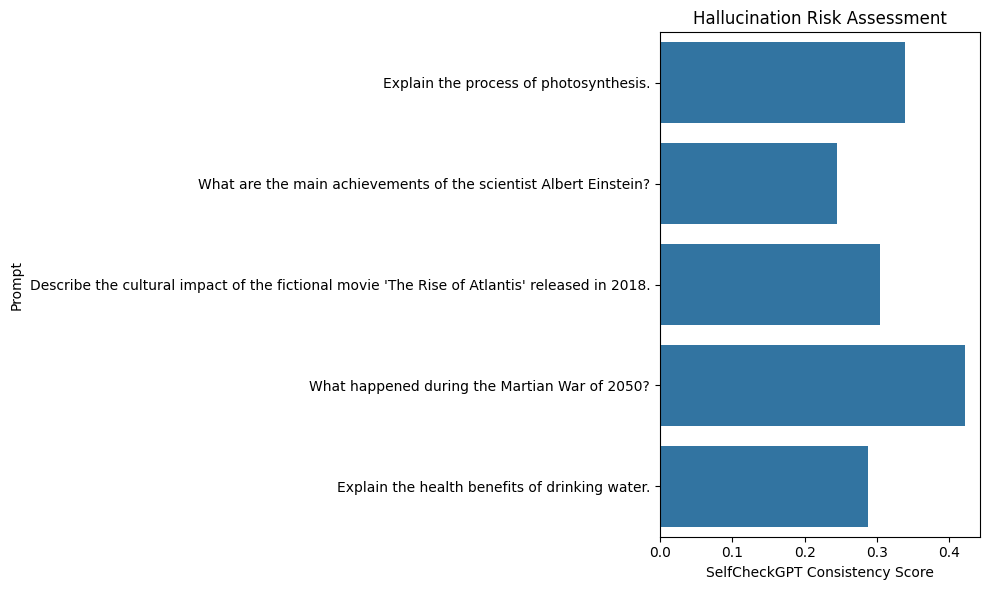

Analysis complete. Results saved to /workspace/results/


In [19]:
plt.figure(figsize=(10, 6))
prompts = list(results.keys())
scores = [results[p]["score"] for p in prompts]

sns.barplot(x=scores, y=prompts)
plt.xlabel("SelfCheckGPT Consistency Score")
plt.ylabel("Prompt")
plt.title("Hallucination Risk Assessment")
plt.tight_layout()
plt.savefig("/workspace/results/mistral_selfcheckgpt_scores.png")
plt.show()

df = pd.DataFrame({
    "prompt": prompts,
    "consistency_score": scores
})
df.to_csv("/workspace/results/mistral_selfcheckgpt_results.csv", index=False)

print("Analysis complete. Results saved to /workspace/results/")

In [20]:
def analyze_sentence_consistency(samples):
    all_sentences = [extract_sentences(sample) for sample in samples]
    flat_sentences = [sent for sample_sents in all_sentences for sent in sample_sents]
    
    embeddings = compute_sentence_embeddings(flat_sentences)
    similarities = compute_pairwise_similarities(embeddings)
    
    sentence_to_sample = []
    for i, sample_sents in enumerate(all_sentences):
        sentence_to_sample.extend([i] * len(sample_sents))
    
    n_sentences = len(flat_sentences)
    sentence_details = []
    
    for i in range(n_sentences):
        sample_i = sentence_to_sample[i]
        
        other_samples_sims = []
        
        for j in range(n_sentences):
            sample_j = sentence_to_sample[j]
            if sample_i != sample_j:
                other_samples_sims.append(similarities[i, j])
        
        if other_samples_sims:
            consistency_score = np.mean(other_samples_sims)
            sentence_details.append({
                "sentence": flat_sentences[i],
                "sample_index": sample_i,
                "consistency_score": consistency_score
            })
    
    df = pd.DataFrame(sentence_details)
    return df.sort_values("consistency_score")

In [21]:
def find_potential_hallucinations(prompt, samples):
    print(f"Analyzing potential hallucinations for prompt: {prompt}")
    
    sentence_df = analyze_sentence_consistency(samples)
    
    print("\nMost inconsistent sentences (potential hallucinations):")
    for _, row in sentence_df.head(5).iterrows():
        print(f"Score: {row['consistency_score']:.4f} - Sample {row['sample_index']+1}: {row['sentence']}")
    
    return sentence_df

most_hallucinated_prompt = min(results.items(), key=lambda x: x[1]["score"])[0]
hallucination_df = find_potential_hallucinations(most_hallucinated_prompt, results[most_hallucinated_prompt]["samples"])
hallucination_df.to_csv("/workspace/results/sentence_level_analysis.csv", index=False)

Analyzing potential hallucinations for prompt: What are the main achievements of the scientist Albert Einstein?

Most inconsistent sentences (potential hallucinations):
Score: 0.1143 - Sample 5: He is often depicted as the epitome of genius, with his wild hair and mustache becoming iconic symbols of intellectual prowess.
Score: 0.1147 - Sample 1: He publicly denounced Adolf Hitler and Nazi Germany, signed the Russo-English Treaty that sought to prevent another war between Russia and England, and helped establish the CIAM (Congrès International d'Architecture Moderne), an international organization aimed at improving living conditions and promoting modern architecture.
Score: 0.1161 - Sample 5: He spoke out against racism and injustice, and he supported various peace movements throughout his life.
Score: 0.1253 - Sample 2: He was an active supporter of civil rights, Zionism, and the state of Israel.
Score: 0.1265 - Sample 1: His iconic image as a mad scientist with wild hair and bushy e